<h1>KNN model i ansambl KNN modela</h1>
<h2>Uvođenje potrebnih paketa</h2>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import neighbors
from sklearn import metrics
from sklearn import ensemble

In [3]:
import joblib

<h2>Učitavanje pretprocesiranih podataka</h2>

In [4]:
data = pd.read_csv('preprocessed_data.csv', index_col=0)

In [5]:
data.head()

,Education Level,Finance,Science,Business,Computer Science,Arts,Psychology,Commerce,Engineering,Counseling,...,Marketing,Tally ERP,AWS Certified,Mental Health Basics,Digital Marketing,CFA Level 1,Creative Writing,Google Data Analytics,CGPA/Percentage,Recommended Career
0,2,1,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,67,Business Analyst
1,1,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,67,Software Engineer
2,3,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,90,Financial Analyst
3,2,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,75,Clerk
4,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,83,Sales Assistant


In [6]:
target = 'Recommended Career'

<h2>Izdvajanje atributa</h2>

In [7]:
x = data.drop(target, axis=1)

<h2>Izdvajanje i label enkodovanje ciljne promenljive</h2>

In [8]:
target_names = data[target].unique()

y = data[target]

label_encoder = preprocessing.LabelEncoder()
y_encoded = label_encoder.fit_transform( data[target] )

y_encoded

array([ 0, 11,  3, ...,  3, 11,  1], shape=(5000,))

<h2>Podela podataka na skupove za testiranje, validaciju i testiranje i standardizacija</h2>
Vrši se podela podataka na skup nad kojim će model trenirati(trening skup), skup nad kojim će se vršiti evaluacija modela u cilju izbora optimalnih parametara(validacioni skup) i skup koji će se koristiti za evaluaciju modela i davanje konačne ocene tog modela(test skup). Podela se vrši pomoću funkcije train_test_split pri čemu uzimamo trećinu podataka za skup za testiranje, a od preostale dve trećine 80% za treniranje, a 20% za validaciju. Takođe vodimo računa o stratifikaciji da bi udeo klasa ciljne promenljive u svakom skupu bio procentualno jednak. Parametar random_state postavljamo na vrednost 7 kako bi se modeli mogli reprodukovati.

In [9]:
x_trainval, x_test, y_trainval, y_test = model_selection.train_test_split(x, y_encoded, test_size=0.33, stratify=y, random_state=7)

In [10]:
x_train, x_val, y_train, y_val = model_selection.train_test_split(x_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=7)

In [11]:
scalerTrain = preprocessing.StandardScaler()
scalerTrain.fit(x_train)
x_train = scalerTrain.transform(x_train)
x_val = scalerTrain.transform(x_val)

In [12]:
scalerTrainval = preprocessing.StandardScaler()
scalerTrainval.fit(x_trainval)
x_trainval = scalerTrainval.transform(x_trainval)
x_test = scalerTrainval.transform(x_test)

<h2>Izbor optimalnog hiperparametra za KNN model</h2>

In [13]:
def train_and_evaluate(model, x_train, y_train, x_val, y_val):
    model.fit(x_train, y_train)

    return model.score(x_val, y_val)

In [14]:
ks = np.arange(5,30, 5)
ks

array([ 5, 10, 15, 20, 25])

In [15]:
optimal_k = 0
optimal_accuracy = 0

for k in ks:
    model = neighbors.KNeighborsClassifier(n_neighbors=k, metric='cosine')
    score = train_and_evaluate(model, x_train, y_train, x_val, y_val)
        
    if score > optimal_accuracy:
        optimal_accuracy = score
        optimal_k = k

print(optimal_k, optimal_accuracy)

20 0.0955223880597015


In [16]:
ks = np.arange(optimal_k-4, optimal_k+4, 1)
ks

array([16, 17, 18, 19, 20, 21, 22, 23])

In [17]:
optimal_accuracy = 0

for k in ks:
    model = neighbors.KNeighborsClassifier(n_neighbors=k, metric='cosine')
    score = train_and_evaluate(model, x_train, y_train, x_val, y_val)
        
    if score > optimal_accuracy:
        optimal_accuracy = score
        optimal_k = k

print(optimal_k, optimal_accuracy)

19 0.09701492537313433


<h2>Pravljenje i treniranje KNN modela</h2>

In [18]:
model = neighbors.KNeighborsClassifier(n_neighbors=optimal_k, metric='cosine')

In [19]:
model.fit(x_trainval, y_trainval)

,n_neighbors,np.int64(19)
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'cosine'
,metric_params,None
,n_jobs,None


<h2>Evaluacija KNN modela</h2>

In [20]:
model.score(x_train, y_train)

0.20783582089552238

In [21]:
model.score(x_test, y_test)

0.07878787878787878

Ni KNN ne daje bolje rezultate od prethodnih modela

In [22]:
y_test_predicted = model.predict(x_test)

In [23]:
cmatrix = metrics.confusion_matrix(y_test, y_test_predicted)
cmatrix

array([[16, 18, 14,  7, 12,  8,  5,  8, 13, 10, 12,  7],
       [21, 16, 11, 16,  7, 17,  7, 10, 15,  9,  9,  5],
       [17, 22, 13, 11, 16, 14, 10,  4,  9,  7,  5,  8],
       [21, 18, 24, 11, 13,  5, 12,  5,  8,  4, 10,  5],
       [21, 20, 17, 10, 13,  9, 10,  6,  6, 10,  8,  6],
       [18, 13, 22, 11, 14, 15,  9, 12,  7,  4, 11,  6],
       [15, 20, 13, 15, 13, 15,  7,  5, 10, 12,  6, 12],
       [14, 20, 14, 11, 14, 18,  9,  7,  8,  9,  4,  6],
       [11, 23, 13, 15, 14,  8, 11, 13,  9,  6,  8,  7],
       [16, 15, 28, 15,  2,  7, 15,  7,  7,  6, 10,  8],
       [27, 17, 14,  7,  5,  9, 11,  8, 14,  8,  9,  9],
       [16, 18, 16,  6, 11, 14, 13, 15,  6,  7,  8,  8]])

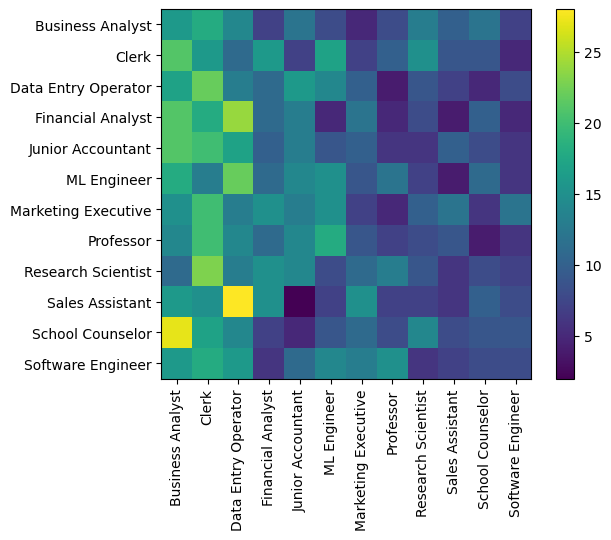

In [24]:
classes_for_display = label_encoder.inverse_transform(range(0, 12))
plt.imshow(metrics.confusion_matrix(y_test, y_test_predicted))
plt.xticks(range(0,  12), labels = classes_for_display, rotation='vertical')
plt.yticks(range(0,  12), labels = classes_for_display)
plt.colorbar()
plt.show()

In [25]:
print(metrics.classification_report(y_test, y_test_predicted))

              precision    recall  f1-score   support

           0       0.08      0.12      0.09       130
           1       0.07      0.11      0.09       143
           2       0.07      0.10      0.08       136
           3       0.08      0.08      0.08       136
           4       0.10      0.10      0.10       136
           5       0.11      0.11      0.11       142
           6       0.06      0.05      0.05       143
           7       0.07      0.05      0.06       134
           8       0.08      0.07      0.07       138
           9       0.07      0.04      0.05       136
          10       0.09      0.07      0.08       138
          11       0.09      0.06      0.07       138

    accuracy                           0.08      1650
   macro avg       0.08      0.08      0.08      1650
weighted avg       0.08      0.08      0.08      1650



<h2>Čuvanje modela</h2>

In [26]:
joblib.dump(label_encoder, 'Models/KNN/label_encoder.pkl')

['Models/KNN/label_encoder.pkl']

In [27]:
joblib.dump(scalerTrain, 'Models/KNN/standard_scaler_train.pkl')

['Models/KNN/standard_scaler_train.pkl']

In [28]:
joblib.dump(scalerTrainval, 'Models/KNN/standard_scaler_trainval.pkl')

['Models/KNN/standard_scaler_trainval.pkl']

In [29]:
joblib.dump(model, 'Models/KNN/model.pkl')

['Models/KNN/model.pkl']

<h2>Izbor optimalnih parametara agregirajućeg ansambla KNN modela</h2>

In [30]:
ks = np.arange(5,30, 5)
n_estimators = np.arange(10, 110, 10)

In [31]:
optimal_k = 0
optimal_estimators = 0
optimal_accuracy = 0

for k in ks:
    for n_estimator in n_estimators:
        base_model = neighbors.KNeighborsClassifier(n_neighbors=k, metric='cosine')
        model = ensemble.BaggingClassifier(base_model, n_estimators=n_estimator, max_samples=0.9, random_state=7)
        score = train_and_evaluate(model, x_train, y_train, x_val, y_val)
        
        if score > optimal_accuracy:
            optimal_accuracy = score
            optimal_estimators = n_estimator
            optimal_k = k
            
print(optimal_k, optimal_estimators, optimal_accuracy)

25 50 0.11044776119402985


<h2>Pravljenje i treniranje modela</h2>

In [32]:
base_model = neighbors.KNeighborsClassifier(n_neighbors=optimal_k, metric='cosine')
model = ensemble.BaggingClassifier(base_model, n_estimators=optimal_estimators)

In [33]:
model.fit(x_trainval, y_trainval)

,estimator,KNeighborsCla...=np.int64(25))
,n_estimators,np.int64(50)
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


<h2>Evaluacija modela</h2>

In [34]:
model.score(x_train, y_train)

0.1917910447761194

In [35]:
model.score(x_test, y_test)

0.07151515151515152

I ovaj model je jako loš

In [36]:
y_test_predicted = model.predict(x_test)

In [37]:
cmatrix = metrics.confusion_matrix(y_test, y_test_predicted)
cmatrix

array([[ 7, 15, 13,  5, 11,  9,  9,  9, 20, 11, 10, 11],
       [12, 10, 13, 16, 10, 14,  8, 12, 13,  9, 15, 11],
       [14, 16,  7,  8, 18, 13, 13,  7, 14,  9, 10,  7],
       [15, 15, 15, 15, 11,  6, 12,  6, 10,  7, 11, 13],
       [17, 10, 16, 11, 10,  7, 13, 11, 10, 12, 12,  7],
       [16, 12, 13,  9, 10, 11, 10, 17, 14,  5, 15, 10],
       [ 8, 13, 13, 13, 12, 13, 12,  3, 11, 16, 13, 16],
       [11, 12, 15,  9, 11, 15, 16,  8, 10, 10,  8,  9],
       [ 6, 18,  7, 13, 12,  8, 13, 14, 11,  9, 16, 11],
       [ 8, 15, 18,  9,  3,  9, 15, 11, 16,  6, 14, 12],
       [16, 13, 11,  9,  6,  6, 14,  8, 17, 13, 12, 13],
       [13, 11, 10,  4, 13, 11,  9, 17, 13, 16, 12,  9]])

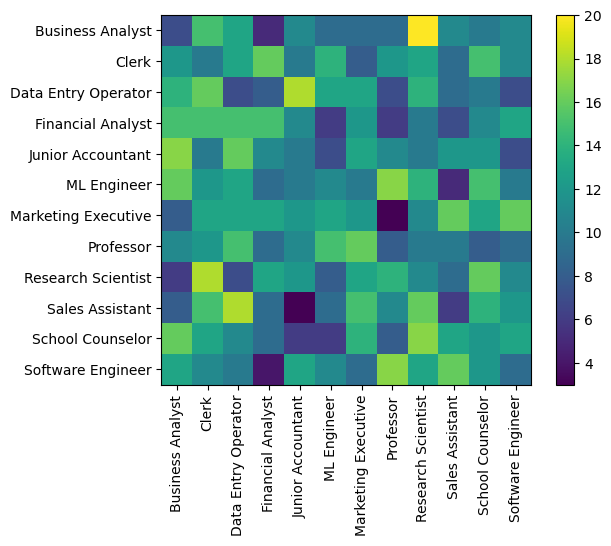

In [38]:
classes_for_display = label_encoder.inverse_transform(range(0, 12))
plt.imshow(metrics.confusion_matrix(y_test, y_test_predicted))
plt.xticks(range(0,  12), labels = classes_for_display, rotation='vertical')
plt.yticks(range(0,  12), labels = classes_for_display)
plt.colorbar()
plt.show()

In [39]:
print(metrics.classification_report(y_test, y_test_predicted))

              precision    recall  f1-score   support

           0       0.05      0.05      0.05       130
           1       0.06      0.07      0.07       143
           2       0.05      0.05      0.05       136
           3       0.12      0.11      0.12       136
           4       0.08      0.07      0.08       136
           5       0.09      0.08      0.08       142
           6       0.08      0.08      0.08       143
           7       0.07      0.06      0.06       134
           8       0.07      0.08      0.07       138
           9       0.05      0.04      0.05       136
          10       0.08      0.09      0.08       138
          11       0.07      0.07      0.07       138

    accuracy                           0.07      1650
   macro avg       0.07      0.07      0.07      1650
weighted avg       0.07      0.07      0.07      1650



<h2>Čuvanje modela</h2>

In [40]:
joblib.dump(label_encoder, 'Models/KNN ensemble/label_encoder.pkl')

['Models/KNN ensemble/label_encoder.pkl']

In [41]:
joblib.dump(scalerTrain, 'Models/KNN ensemble/standard_scaler_train.pkl')

['Models/KNN ensemble/standard_scaler_train.pkl']

In [42]:
joblib.dump(scalerTrainval, 'Models/KNN ensemble/standard_scaler_trainval.pkl')

['Models/KNN ensemble/standard_scaler_trainval.pkl']

In [43]:
joblib.dump(model, 'Models/KNN ensemble/model.pkl')

['Models/KNN ensemble/model.pkl']